# J-lens readout on Qwen3-4B — pre-fitted lens vs logit lens

Does the Jacobian lens show the model's internal representations where the logit lens
does not? The lens is Anthropic's own, fitted by this library's `fit_lens.py` on 1000
WikiText-103 sequences and downloaded from `neuronpedia/jacobian-lens` — nothing is
fitted here. Readouts are scored over the 551 items of `data/evaluations`, whose
`intermediates` are the words the model must "think about" on the way to its answer but
does not say.

**Answer (this run, §6).** Mixed, and the headline is negative. Qualitatively the J-lens
does what the paper describes: on *"the currency used in the country shaped like a boot"* it
reads ` Italy` / `意大利` / `欧元` at layer 24 — ` Italy` at rank 1, where the logit lens has
it at rank 23 and is still reading function words (` called`, ` currently`). But
quantitatively, over all 551 items, **the pre-fitted J-lens does not beat the logit lens on
this protocol**: pass@1 over intermediates is 0.067 against the logit lens's 0.133, and the
J-lens loses at every k, both over all layers (§4b) and restricted to the mid-depth
workspace band (§4c). Masking the readout to word-like tokens does not change the verdict
(§4d), so this is not an artifact of Qwen's CJK-heavy vocabulary. The lens is nevertheless
far from a no-op — cos(W_U, W_U J_l) runs from 0.05 at layer 0 to 0.74 at layer 33 (§5) —
and it is clearly worse than the logit lens in the first third of the network, where it
returns mostly punctuation. Note that this is the *readout-ranking* claim only, and it is
the one claim in this directory that fails: on the same model and the same lens,
`verbal_report.ipynb` reproduces the paper's own Spearman metric (J-lens 0.26 vs logit lens
0.13 at layer 12) and `concept_swap.ipynb` reproduces the causal claim with logit-lens
directions scoring exactly 0.000 in the early bands where J-lens directions reach 43%.

## Method

**Lens.** `lens(h) = unembed(J_l h)` with `J_l = E[d h_final / d h_l]` averaged over source
positions, later positions and a pretraining-like corpus. `J_l` is a fitted
`d_model x d_model` matrix per layer; applying it is one matmul, so the readout costs the
same as the logit lens. The logit-lens baseline is the same pipeline with `J_l = I`.

**Shared activations.** `jlens.evaluation.evaluate_paired` takes one forward pass per
prompt and reads both lenses off the same pre-final-norm block outputs, so the comparison
cannot be confounded by sampling or by a different forward.

**Scoring** (`data/evaluations/README.md`): at each layer a word's score is its 1-based
rank in the lens's vocabulary distribution at the dataset's readout position, min over
spellings. pass@k averages, within an item, the fraction of words whose best-over-layers
rank is <= k, then averages over items. `control` words are another item's intermediates
and give the chance baseline.

**Why this is the claim.** The intermediates are not in the prompt and not in the output.
A readout that ranks them highly is reporting something the model computed internally.

## Setup

In [1]:
import os
import sys
from pathlib import Path

REPO_URL = "https://github.com/ai360-project-school-j-lens/jacobian-lens-gpt2.git"
REPO_DIR = os.path.abspath("jacobian-lens-gpt2")

# Opened from a clone (notebooks/<lens>/): use the repository root above the notebook.
local_repo = next((p for p in [Path.cwd(), *Path.cwd().parents] if (p / "jlens" / "workspace.py").is_file()), None)
if local_repo is not None:
    REPO_DIR = str(local_repo)
elif os.path.isdir(REPO_DIR):
    !git -C {REPO_DIR} pull --ff-only
else:
    !git clone {REPO_URL} {REPO_DIR}
sys.path.append(REPO_DIR)

In [2]:
import matplotlib.pyplot as plt
import pandas as pd
import torch
from IPython.display import display
from transformers import AutoModelForCausalLM, AutoTokenizer

import jlens
from jlens.evaluation import (
    DATASETS,
    evaluate_paired,
    identity_lens,
    jacobian_lens,
    layer_hit_rate,
    layer_median_rank,
    load_eval,
    logit_lens,
    pass_at_k,
    plot_layer_curves,
    readout_position,
    spelling_ids,
)
from jlens.hooks import ActivationRecorder
from jlens.metrics import evaluate_distributions, lens_vector_geometry
from jlens.reference_plots import (
    intermediate_rank_sweep,
    plot_distribution_summary,
    plot_intermediate_sweep,
    plot_lens_comparison,
)
from jlens.vis import _meaningful_token_mask
from jlens.workspace import final_norm_centers

pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 240)

In [3]:
MODEL_ID = os.environ.get("JLENS_MODEL_ID", "Qwen/Qwen3-4B")
LENS_REPO = "neuronpedia/jacobian-lens"
LENS_FILE = {  # lenses fitted by this library's fit_lens.py on 1000 WikiText-103 x 128 tokens
    "Qwen/Qwen3-4B": "qwen3-4b/jlens/Salesforce-wikitext/Qwen3-4B_jacobian_lens.pt",
    "Qwen/Qwen3-1.7B": "qwen3-1.7b/jlens/Salesforce-wikitext/Qwen3-1.7B_jacobian_lens.pt",
}[MODEL_ID]
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
DTYPE = torch.bfloat16 if DEVICE == "cuda" else torch.float32
SLUG = MODEL_ID.split("/")[-1].lower()
RUN_DIR = Path(os.environ.get("JLENS_RUN_DIR", Path(REPO_DIR) / "runs" / SLUG))
RUN_DIR.mkdir(parents=True, exist_ok=True)
torch.manual_seed(0)

In [4]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)
hf_model = AutoModelForCausalLM.from_pretrained(MODEL_ID, dtype=DTYPE).to(DEVICE)
model = jlens.from_hf(hf_model, tokenizer)
lens = jlens.JacobianLens.from_pretrained(LENS_REPO, filename=LENS_FILE)

# Qwen3 is RMSNorm, so lens directions carry no centering term; probed, not assumed.
CENTERS = final_norm_centers(model)
assert lens.d_model == model.d_model, (lens.d_model, model.d_model)
print(f"{model}  layout={model.layout.path}  centers={CENTERS}")
print(f"lens: {lens.n_prompts} prompts, layers {lens.source_layers[0]}-{lens.source_layers[-1]}")
print(f"tokenizer: bos_token_id={tokenizer.bos_token_id}  dtype={DTYPE}  device={DEVICE}")

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 1 files:   0%|          | 0/1 [00:00<?, ?it/s]

HFLensModel(Qwen3ForCausalLM, n_layers=36, d_model=2560)  layout=model  centers=False
lens: 479 prompts, layers 0-34
tokenizer: bos_token_id=None  dtype=torch.bfloat16  device=cuda


In [5]:
LAYER_STRIDE = max(1, model.n_layers // 12)
# Pickled, not CSV: both frames carry per-layer numpy arrays in a single cell.
OUT_WORDS = RUN_DIR / "readout_words.pkl"
OUT_ITEMS = RUN_DIR / "readout_items.pkl"
# Recorded with the results, per AGENTS.md's Experiment Configuration.
RUN_INFO = {
    "model_id": MODEL_ID,
    "dtype": str(DTYPE),
    "device": DEVICE,
    "n_layers": model.n_layers,
    "d_model": model.d_model,
    "lens_file": LENS_FILE,
    "lens_n_prompts": lens.n_prompts,
    "lens_corpus": "Salesforce/wikitext wikitext-103-raw-v1, 128 tokens/sequence",
    "final_norm_centers": CENTERS,
    "transformers": __import__("transformers").__version__,
    "torch": torch.__version__,
}
RUN_INFO

{'model_id': 'Qwen/Qwen3-4B',
 'dtype': 'torch.bfloat16',
 'device': 'cuda',
 'n_layers': 36,
 'd_model': 2560,
 'lens_file': 'qwen3-4b/jlens/Salesforce-wikitext/Qwen3-4B_jacobian_lens.pt',
 'lens_n_prompts': 479,
 'lens_corpus': 'Salesforce/wikitext wikitext-103-raw-v1, 128 tokens/sequence',
 'final_norm_centers': False,
 'transformers': '5.19.0',
 'torch': '2.14.0+cu130'}

## 1. Datasets

Six prompt sets from `data/evaluations`. Each item has a `prompt`, the `intermediates`
the model should pass through, and sometimes the `target` answer itself.

In [6]:
evals = {dataset: load_eval(REPO_DIR, dataset) for dataset in DATASETS}
print({dataset: len(items) for dataset, items in evals.items()})
print("total items:", sum(len(items) for items in evals.values()))
evals["multihop"][0]

{'multihop': 93, 'multilingual': 107, 'order-ops': 55, 'poetry': 98, 'association': 102, 'typo': 96}
total items: 551


{'name': 'carnival-ocean',
 'prompt': 'Fact: The ocean on the coast of the country where Carnival is most famously celebrated is the ',
 'target': 'Atlantic',
 'intermediates': ['Brazil']}

## 2. Sanity gates

Nothing below is worth reading unless these pass. The first checks that this adapter's
`unembed` really is the model's own head on this architecture; the second that the lens
machinery reduces exactly to the logit lens when `J_l = I`.

In [7]:
PROBE = "Fact: The currency used in the country shaped like a boot is"
ids = model.encode(PROBE)
with torch.no_grad():
    reference = hf_model(input_ids=ids).logits[0].float().cpu()
handwritten = logit_lens(model, PROBE)[-1].float().cpu()
rel_err = ((handwritten - reference).abs().max() / reference.abs().max()).item()
# bf16 carries ~3 decimal digits, so ~1e-3 is the noise floor here; a layout mistake
# (wrong norm, double unembed) would be O(1) and is what this gate is for.
GATE = 1e-4 if DTYPE == torch.float32 else 1e-2
print(f"unembed(final block) vs hf_model.logits: max rel err {rel_err:.2e}  (tol {GATE:g})")
assert rel_err < GATE, rel_err

unembed(final block) vs hf_model.logits: max rel err 0.00e+00  (tol 0.01)


In [8]:
identity = jacobian_lens(model, identity_lens(model), PROBE)
baseline = logit_lens(model, PROBE)
max_diff = (identity - baseline).abs().max().item()
print(f"identity lens vs logit lens: max abs diff {max_diff:.2e}")
assert max_diff < 1e-3, max_diff

identity lens vs logit lens: max abs diff 0.00e+00


## 3. What the two lenses read at the readout position

The prompt needs *Italy* (shape -> country) to get to *euro* (country -> currency).
*Italy* is the internal step: it is in neither the prompt nor the answer.

In [9]:
jl = jacobian_lens(model, lens, PROBE)
ll = logit_lens(model, PROBE)
position = -1
rows = []
for layer in range(0, model.n_layers, LAYER_STRIDE):
    for name, logits in (("J-lens", jl), ("logit lens", ll)):
        top = logits[layer, position].topk(6).indices.tolist()
        rows.append({"layer": layer, "lens": name,
                     "top-6": " ".join(repr(tokenizer.decode([i])) for i in top)})
display(pd.DataFrame(rows).pivot(index="layer", columns="lens", values="top-6"))
print("model output:", [tokenizer.decode([i]) for i in jl[-1, position].topk(6).indices.tolist()])

lens,J-lens,logit lens
layer,,
0,' –' ' …\n\n' ' ….' '….\n\n' '”.\n\n' '’.\n\n','/is' 'lington' '館' 'rael' '紋' '该县'
3,'…”' '”\n' '.”\n' '…”\n\n' '”，' '”.\n\n','ocratic' 'ucht' '/is' 'omers' 'rael' '-roll'
6,'`.\n\n' '”。\n\n' '`\n\n' '`.\n' '。\n\n' '”.\n\n','[number' 'もっと' '間違い' 'oven' '끔' 'yı'
9,' \\`' '`.\n\n' '`.\n' '`;\n\n' '帼' ' &#',' 물론' '끔' ' Федер' '全过程' '-but' '[number'
12,' \\`' '`.\n\n' '`.\n' ' […' ' Britain' '。\n','-shaped' ' shaped' '瘾' '_lib' '[number' 'ão'
15,'吗' '。\\' '？\n' '哪个' ' \\`' '？\n\n','蓉' '-shaped' '地区的' '꼴' ' victories' '最多的'
18,'？\n' '？\n\n' ')?\n' '？”' ')?\n\n' '?”\n\n',' countries' '全国人民' ' located' 'eder' ' namely...
21,')?\n\n' ')?\n' '?</' '.*/\n' '?”\n\n' ';*/\n',' victories' ' where' '其中之一' ' continent' ' on...
24,' Italy' '意大利' '欧元' '英镑' 'Italy' ' Italian',' called' ' currently' ' named' ' typically' '...


model output: [' the', ' called', ' ', ' Euro', '?\n', '欧元']


### Rank of the intermediate (` Italy`) and the target (` euro`) by layer

The J-lens should put *Italy* near the top somewhere in the middle of the network, and
the logit lens should not.

,J-lens ' Italy',logit ' Italy',J-lens ' euro',logit ' euro'
layer,,,,
0,3401,78086,13211,90452
3,30681,129538,111869,117186
6,65564,40568,27978,111747
9,105486,47562,23672,47653
12,157,1431,3789,108592
15,20782,5219,34432,21085
18,2428,8101,42185,13699
21,4004,978,41102,9647
24,1,23,71,256


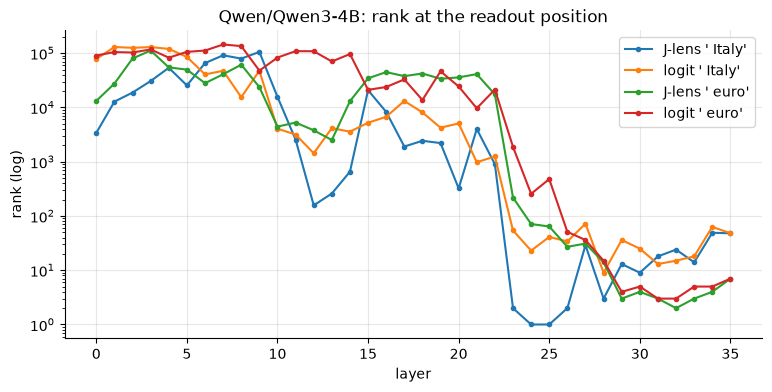

In [10]:
# 1-based rank of a word's first token at every layer.
def rank_of(logits, word, position=-1):
    ids = tokenizer.encode(word, add_special_tokens=False)
    scores = logits[:, position]
    return ((scores > scores[:, ids[0]].unsqueeze(-1)).sum(-1) + 1).cpu().numpy()

ranks = pd.DataFrame({
    "J-lens ' Italy'": rank_of(jl, " Italy"),
    "logit ' Italy'": rank_of(ll, " Italy"),
    "J-lens ' euro'": rank_of(jl, " euro"),
    "logit ' euro'": rank_of(ll, " euro"),
}, index=range(model.n_layers))
ranks.index.name = "layer"
display(ranks.iloc[::LAYER_STRIDE])
fig, ax = plt.subplots(figsize=(9, 4))
for column in ranks:
    ax.plot(ranks.index, ranks[column], marker=".", label=column)
ax.set_yscale("log")
ax.set_xlabel("layer")
ax.set_ylabel("rank (log)")
ax.set_title(f"{MODEL_ID}: rank at the readout position")
ax.legend()
ax.grid(alpha=0.3)
ax.spines[["top", "right"]].set_visible(False)
plt.show()

## 4. All 551 items

One forward pass per prompt, both lenses off the same activations. Cached to CSV, so
re-executing the notebook does not repeat it.

In [11]:
if OUT_WORDS.exists() and OUT_ITEMS.exists():
    words, items = pd.read_pickle(OUT_WORDS), pd.read_pickle(OUT_ITEMS)
    print("loaded cached readouts")
else:
    words, items = evaluate_paired(model, lens, evals)
    words.to_pickle(OUT_WORDS)
    items.to_pickle(OUT_ITEMS)
print(len(words), "word rows,", len(items), "item rows")
words.head(3)

loaded cached readouts
4186 word rows, 1102 item rows


,dataset,item,kind,word,role,single_token,in_prompt,ranks,best_rank,best_layer,lens
0,multihop,carnival-ocean,intermediate,Brazil,0,True,False,"[4569, 7887, 3332, 11710, 25595, 96346, 52092,...",115,35,logit lens
1,multihop,carnival-ocean,control,China,0,True,False,"[42784, 39255, 54137, 89427, 84945, 85991, 297...",797,20,logit lens
2,multihop,carnival-ocean,target,Atlantic,0,True,False,"[49186, 43444, 42727, 62782, 61058, 21534, 195...",1,28,logit lens


### 4a. pass@k over all words, by kind

In [12]:
scores = pass_at_k(words)
display(scores.pivot_table(index=["dataset", "kind"], columns=["lens", "k"], values="score").round(3))

lens                      J-lens                      logit lens                     
k                            1      5      10     100        1      5      10     100
dataset      kind                                                                    
association  control       0.000  0.000  0.000  0.020      0.000  0.010  0.010  0.049
             intermediate  0.000  0.000  0.010  0.098      0.010  0.020  0.029  0.147
multihop     control       0.033  0.054  0.065  0.217      0.033  0.054  0.065  0.293
             intermediate  0.161  0.376  0.495  0.774      0.204  0.360  0.446  0.819
             target        0.452  0.591  0.624  0.774      0.452  0.613  0.688  0.882
multilingual control       0.000  0.006  0.009  0.055      0.005  0.024  0.027  0.058
             intermediate  0.201  0.327  0.383  0.582      0.215  0.369  0.460  0.659
             target        0.458  0.673  0.757  0.925      0.355  0.673  0.729  0.907
order-ops    control       0.010  0.020  0.110  0.640      0.010  0.020  0.110  0.670
             intermediate  0.009  0.100  0.245  0.709      0.027  0.127  0.245  0.773
             target        0.036  0.055  0.073  0.564      0.036  0.055  0.073  0.636
poetry       control       0.000  0.000  0.010  0.071      0.000  0.010  0.031  0.102
             intermediate  0.000  0.010  0.020  0.112      0.000  0.010  0.020  0.184
typo         control       0.000  0.000  0.000  0.042      0.000  0.000  0.010  0.094
             intermediate  0.031  0.260  0.323  0.740      0.344  0.594  0.750  0.958

### 4b. Intermediates only — the headline comparison

`control` is the chance baseline (another item's intermediates), so the number that
matters is intermediate minus control, J-lens vs logit lens.

In [13]:
summary = (pass_at_k(words)
           .pivot_table(index=["kind", "k"], columns="lens", values="score")
           .round(3))
summary["J - logit"] = (summary["J-lens"] - summary["logit lens"]).round(3)
display(summary)

lens              J-lens  logit lens  J - logit
kind         k                                 
control      1     0.007       0.008     -0.001
             5     0.013       0.020     -0.007
             10    0.032       0.042     -0.010
             100   0.174       0.211     -0.037
intermediate 1     0.067       0.133     -0.066
             5     0.179       0.247     -0.068
             10    0.246       0.325     -0.079
             100   0.502       0.590     -0.088
target       1     0.315       0.281      0.034
             5     0.440       0.447     -0.007
             10    0.484       0.497     -0.013
             100   0.754       0.808     -0.054

### 4c. Restricted to the workspace band

pass@k above takes the best rank over *all* layers, which flatters the logit lens: at the
last layers it is the model's own output distribution. The paper reads the workspace over a
mid-depth band instead (`data/evaluations/README.md`), so this repeats the comparison with
only those layers available to both lenses.

In [14]:
WORKSPACE_BAND = list(range(round(0.33 * model.n_layers), round(0.78 * model.n_layers)))
print("band layers:", WORKSPACE_BAND[0], "-", WORKSPACE_BAND[-1])
band = (pass_at_k(words, layers=WORKSPACE_BAND)
        .pivot_table(index=["kind", "k"], columns="lens", values="score")
        .round(3))
band["J - logit"] = (band["J-lens"] - band["logit lens"]).round(3)
display(band)

band layers: 12 - 27


lens              J-lens  logit lens  J - logit
kind         k                                 
control      1     0.000       0.003     -0.003
             5     0.000       0.009     -0.009
             10    0.000       0.014     -0.014
             100   0.034       0.130     -0.096
intermediate 1     0.013       0.073     -0.060
             5     0.078       0.150     -0.072
             10    0.111       0.216     -0.105
             100   0.269       0.479     -0.210
target       1     0.025       0.038     -0.013
             5     0.091       0.105     -0.014
             10    0.129       0.156     -0.027
             100   0.255       0.409     -0.154

In [15]:
display(pass_at_k(words[words.kind.eq("intermediate")], layers=WORKSPACE_BAND)
        .pivot_table(index="dataset", columns=["lens", "k"], values="score").round(3))

lens         J-lens                      logit lens                     
k               1      5      10     100        1      5      10     100
dataset                                                                 
association   0.000  0.000  0.000  0.049      0.010  0.010  0.010  0.078
multihop      0.022  0.151  0.226  0.430      0.097  0.199  0.231  0.625
multilingual  0.054  0.131  0.159  0.376      0.086  0.241  0.350  0.593
order-ops     0.000  0.000  0.000  0.155      0.018  0.045  0.100  0.609
poetry        0.000  0.000  0.000  0.041      0.000  0.010  0.010  0.061
typo          0.000  0.188  0.281  0.562      0.229  0.396  0.594  0.906

### 4d. Is the gap an artifact of Qwen's vocabulary?

The J-lens readout is visibly full of CJK tokens and punctuation (§3), and a full-vocabulary
rank punishes that even where the right concept is present. `jlens.vis` already has the mask
used for display (`mask_display=True`); here it is applied to the *ranks*, over the two
datasets where both lenses do best. If the J-lens only looked worse because of non-word
tokens, masking would close the gap.

In [16]:
wordlike = _meaningful_token_mask(tokenizer, model._lm_head.weight.shape[0], model.input_device)
print(f"word-like tokens: {int(wordlike.sum())} of {wordlike.numel()}")

rows = []
for dataset in ("multihop", "multilingual"):
    for item in evals[dataset]:
        prompt = item["prompt"].rstrip()
        ids = model.encode(prompt)
        position = readout_position(tokenizer, ids[0].tolist(), dataset)
        with torch.no_grad(), ActivationRecorder(model.layers, at=WORKSPACE_BAND) as recorder:
            model.forward(ids)
            acts = {l: recorder.activations[l].detach() for l in WORKSPACE_BAND}
        for word in item["intermediates"]:
            ids_of_word = sorted(spelling_ids(tokenizer, word))
            if not ids_of_word:
                continue
            index = torch.tensor(ids_of_word, device=model.input_device)
            best = {"J-lens": (10**9, 10**9), "logit lens": (10**9, 10**9)}
            for layer in WORKSPACE_BAND:
                h = acts[layer][0, position].float()
                for name, residual in (("J-lens", lens.transport(h, layer)), ("logit lens", h)):
                    logits = model.unembed(residual).float()
                    full = int((logits > logits[index].max()).sum()) + 1
                    masked_logits = logits.masked_fill(~wordlike, -float("inf"))
                    masked = int((masked_logits > masked_logits[index].max()).sum()) + 1
                    best[name] = (min(best[name][0], full), min(best[name][1], masked))
            for name, (full, masked) in best.items():
                rows.append({"dataset": dataset, "lens": name, "full": full, "masked": masked})

masked_ranks = pd.DataFrame(rows)
table = pd.concat(
    {f"@{k}": masked_ranks.assign(full_hit=masked_ranks.full <= k, masked_hit=masked_ranks.masked <= k)
     .groupby(["dataset", "lens"])[["full_hit", "masked_hit"]].mean()
     for k in (1, 5, 10)}, axis=1).round(3)
display(table)

word-like tokens: 121220 of 151936


@1                  @5                 @10           
                        full_hit masked_hit full_hit masked_hit full_hit masked_hit
dataset      lens                                                                  
multihop     J-lens        0.019      0.019    0.136      0.146    0.204      0.223
             logit lens    0.087      0.087    0.184      0.194    0.214      0.214
multilingual J-lens        0.056      0.110    0.131      0.238    0.159      0.327
             logit lens    0.086      0.133    0.241      0.313    0.350      0.393

### 4e. Where in depth does each lens find the intermediates?

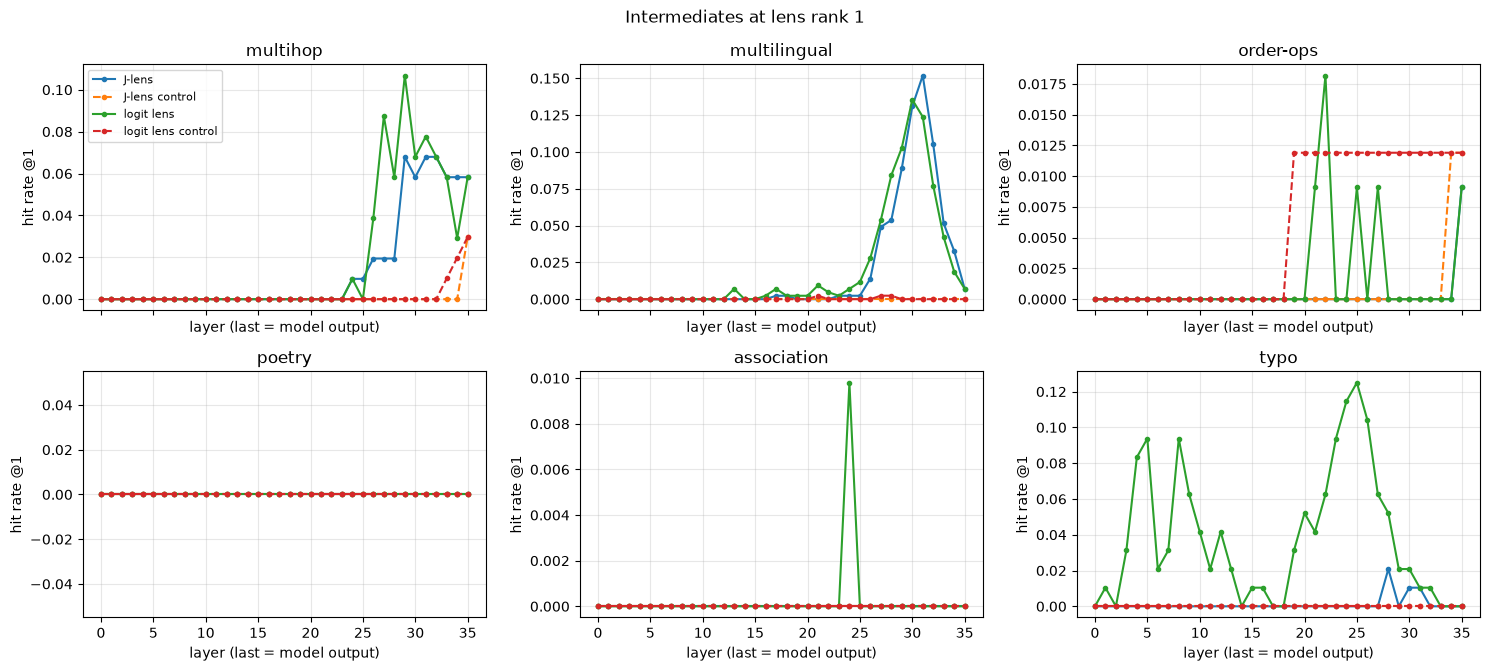

In [17]:
hits, medians = {}, {}
for name in ("J-lens", "logit lens"):
    for kind in ("intermediate", "control"):
        subset = words[words.lens.eq(name) & words.kind.eq(kind)]
        label = name if kind == "intermediate" else f"{name} control"
        hits[label] = layer_hit_rate(subset, k=1)
        medians[label] = layer_median_rank(subset)
plot_layer_curves(hits, "Intermediates at lens rank 1", "hit rate @1")
plt.show()

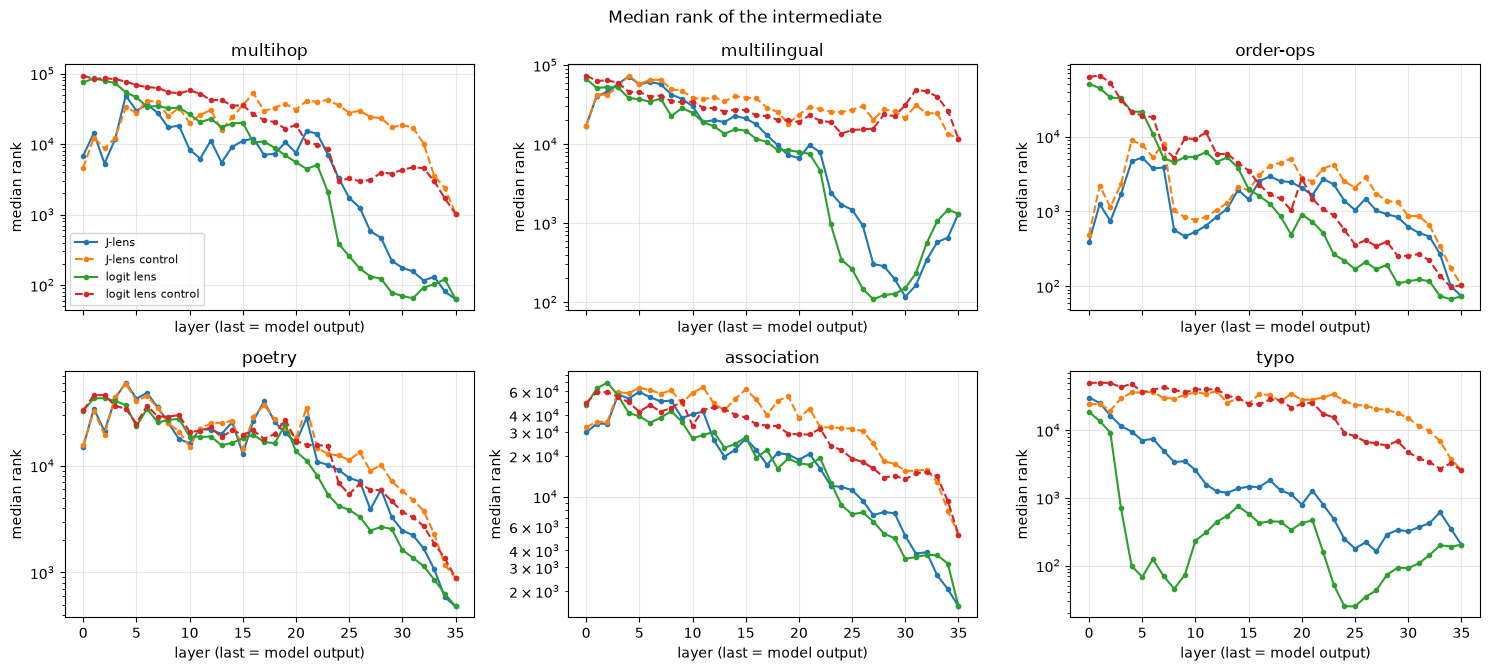

In [18]:
plot_layer_curves(medians, "Median rank of the intermediate", "median rank", logy=True)
plt.show()

### 4f. Figure 52 adaptation: intermediate rank sweep over k

lens,J-lens,logit lens
dataset,,
association,0.023,0.045
multihop,0.481,0.483
multilingual,0.400,0.460
order-ops,0.290,0.297
poetry,0.036,0.040
typo,0.334,0.691


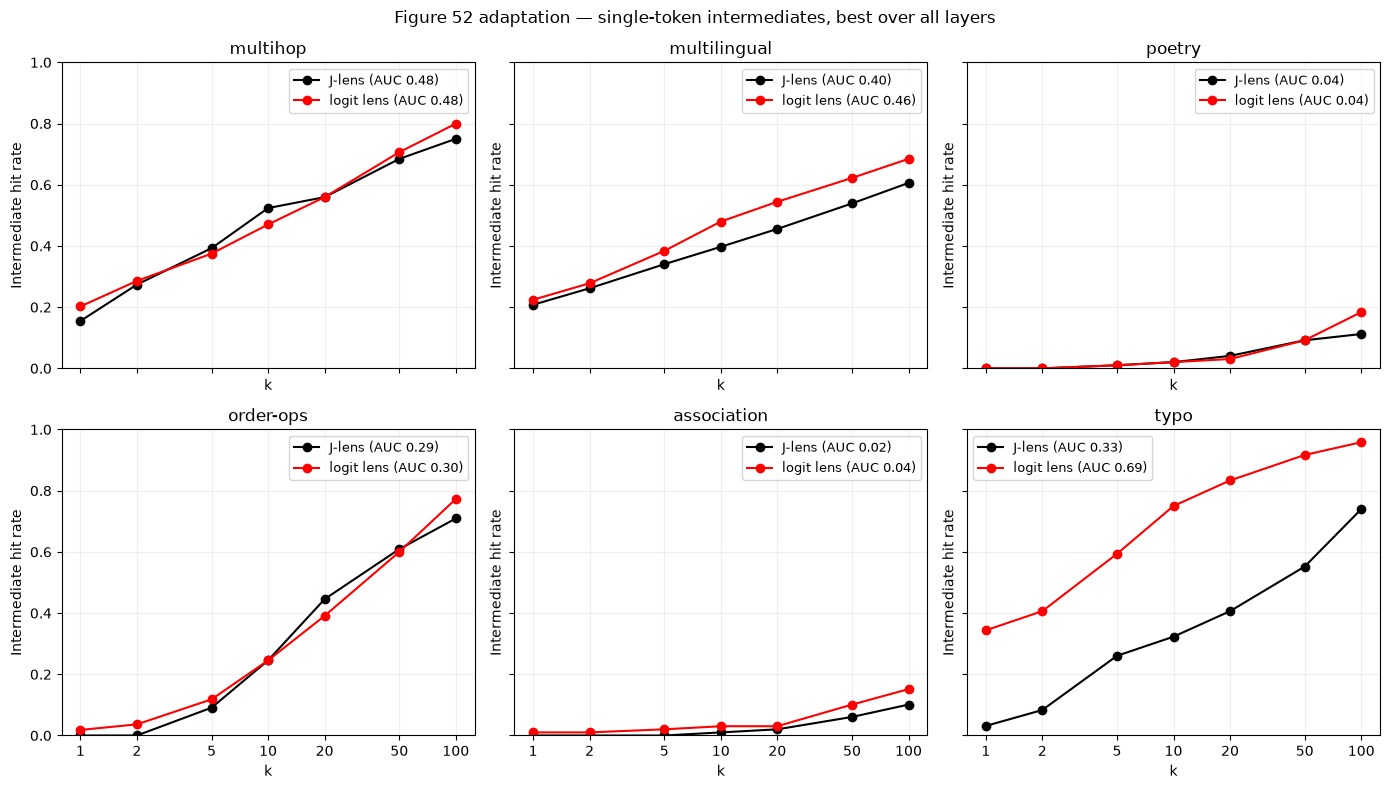

In [19]:
sweep = intermediate_rank_sweep(words)
# AUC is trapezoidal in log(k), normalised by log(k_max/k_min): one number per lens/task.
display(sweep.scores.pivot_table(index="dataset", columns="lens", values="auc").round(3))
plot_intermediate_sweep(sweep)
plt.show()

## 5. Held-out distribution metrics (Figures 55/56 adaptations)

How far each layer's readout is from the model's own output distribution, on held-out
text rather than the evaluation prompts. These are the repo's adaptations, not numbers
the paper reports.

In [20]:
HELD_OUT = [item["prompt"] for dataset in ("poetry", "association") for item in evals[dataset][:24]]
distributions = evaluate_distributions(model, lens, HELD_OUT,
                                       layers=list(range(0, model.n_layers, LAYER_STRIDE)))
display(distributions.layers.round(4))

held-out lens metrics:   0%|          | 0/48 [00:00<?, ?it/s]

,lens,layer,is_final,kl_model_to_lens,entropy,top1_agreement,n_tokens,n_texts,n_texts_used,weighting
0,logit lens,0,False,18.1914,3.1797,0.0000,1254,48,48,token
1,logit lens,3,False,15.5483,5.4687,0.0000,1254,48,48,token
2,logit lens,6,False,11.2657,7.0056,0.0024,1254,48,48,token
3,logit lens,9,False,10.2833,6.6578,0.0040,1254,48,48,token
4,logit lens,12,False,9.0155,6.9241,0.0120,1254,48,48,token
5,logit lens,15,False,8.4566,7.1746,0.0104,1254,48,48,token
6,logit lens,18,False,6.8302,7.1581,0.0215,1254,48,48,token
7,logit lens,21,False,5.9027,6.4942,0.0726,1254,48,48,token
8,logit lens,24,False,4.3039,3.9440,0.1443,1254,48,48,token
9,logit lens,27,False,3.3847,2.8447,0.2440,1254,48,48,token


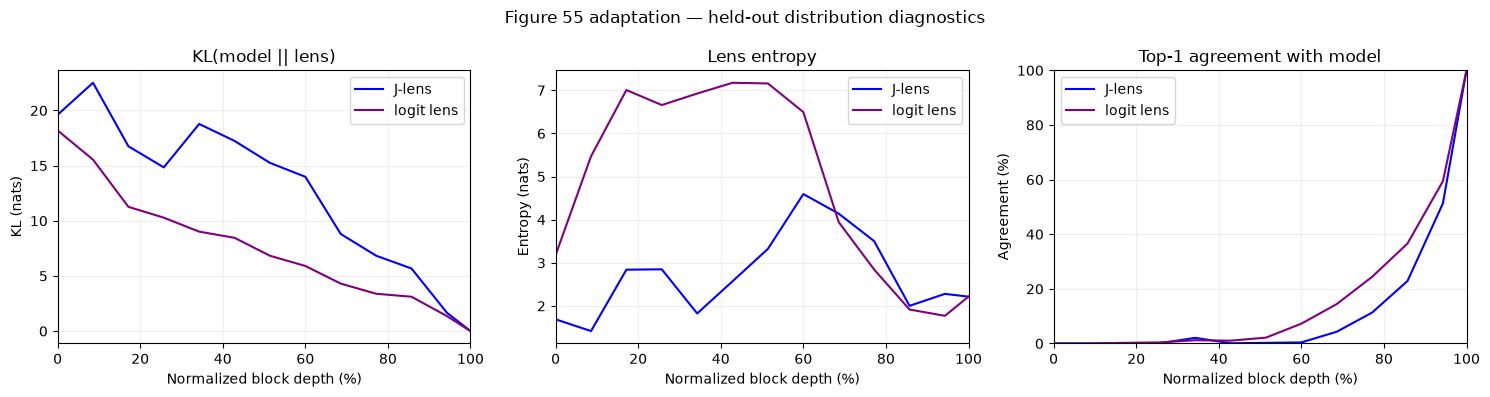

In [21]:
plot_distribution_summary(distributions.layers, n_layers=model.n_layers)
plt.show()

lens vector geometry:   0%|          | 0/13 [00:00<?, ?it/s]

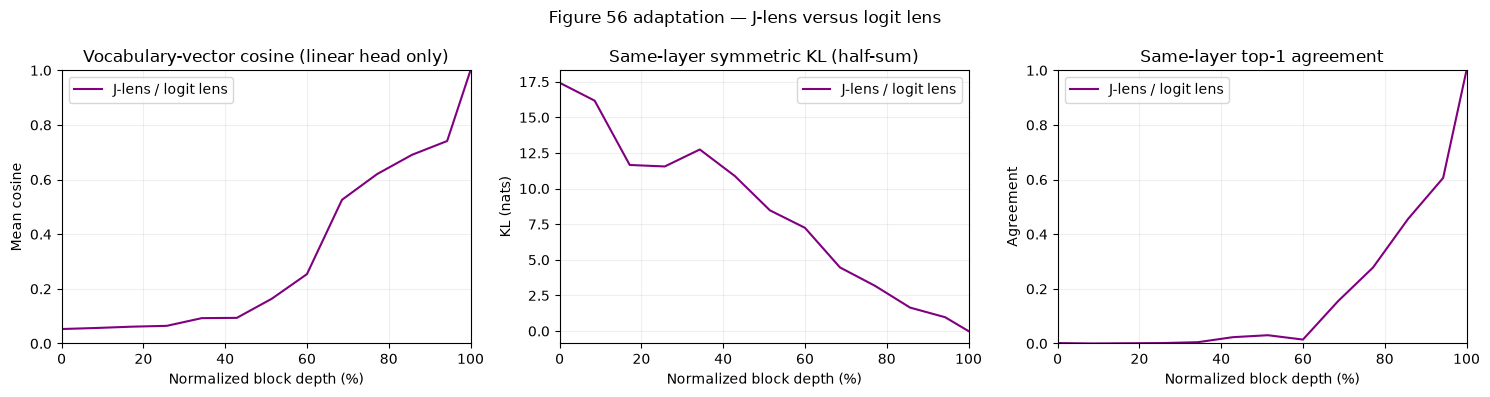

,layer,is_final,status,reason,mean_cosine,n_vocab,n_valid_vectors,n_zero_vectors,weighting,convention
0,0,False,ok,,0.0530,151936,151936,0,vocabulary,linear_head_only: W_U vs W_U @ J
1,3,False,ok,,0.0568,151936,151936,0,vocabulary,linear_head_only: W_U vs W_U @ J
2,6,False,ok,,0.0616,151936,151936,0,vocabulary,linear_head_only: W_U vs W_U @ J
3,9,False,ok,,0.0646,151936,151936,0,vocabulary,linear_head_only: W_U vs W_U @ J
4,12,False,ok,,0.0928,151936,151936,0,vocabulary,linear_head_only: W_U vs W_U @ J
5,15,False,ok,,0.0938,151936,151936,0,vocabulary,linear_head_only: W_U vs W_U @ J
6,18,False,ok,,0.1641,151936,151936,0,vocabulary,linear_head_only: W_U vs W_U @ J
7,21,False,ok,,0.2540,151936,151936,0,vocabulary,linear_head_only: W_U vs W_U @ J
8,24,False,ok,,0.5261,151936,151936,0,vocabulary,linear_head_only: W_U vs W_U @ J
9,27,False,ok,,0.6201,151936,151936,0,vocabulary,linear_head_only: W_U vs W_U @ J


In [22]:
geometry = lens_vector_geometry(model, lens, layers=list(range(0, model.n_layers, LAYER_STRIDE)))
plot_lens_comparison(distributions.pairs, geometry, n_layers=model.n_layers)
plt.show()
display(geometry.round(4))

## 6. Conclusions

* **The readout claim does not reproduce on Qwen3-4B.** Over 551 items the pre-fitted
  J-lens ranks the intermediates *worse* than the logit lens at every k: pass@1 0.067 vs
  0.133, pass@10 0.246 vs 0.325 (§4b). Restricting both lenses to the mid-depth workspace
  band widens the gap rather than closing it (0.013 vs 0.073 at k=1, §4c), and masking the
  readout to word-like tokens does not close it either (§4d). The one dataset where the
  logit lens wins overwhelmingly is `typo` (0.031 vs 0.344), where the intermediates are
  corrected spellings of tokens already in the prompt — a copy, which the logit lens reads
  directly off the residual stream.
* **But the lens is doing something real.** At layer 24 of the worked example its top-1 is
  ` Italy`, the bridge entity, which appears in neither prompt nor answer, while the logit
  lens has it at rank 23 and reads ` called` / ` currently` (§3). `lens_vector_geometry`
  confirms `J_l` is far from the identity in the first two thirds of the network
  (cos(W_U, W_U J_l) = 0.05 at layer 0, 0.53 at 24, 0.74 at 33, §5), so this is not the
  logit lens in disguise.
* **Early layers are the weak point.** Below layer ~21 the J-lens top-1 is almost always
  punctuation or a code fence, and its KL to the model output is *higher* than the logit
  lens's at every layer (§5). This is the plain Jacobian lens's known failure mode, and the
  stated motivation for the later J++ variant, which is deliberately not used here.
* **The readout metric is not the paper's main evidence.** The paper validates the J-space
  causally, and those experiments do reproduce here on the same model and lens:
  `concept_swap.ipynb` gets 43-49% swap success against 1-5% for norm-matched random
  directions, with logit-lens directions at 0.000 in the early bands; `verbal_report.ipynb`
  reproduces the paper's Spearman metric with the J-lens ahead at every layer tested. A lens
  can carry a causally effective direction without winning a full-vocabulary rank contest
  against the logit lens, and on Qwen3-4B that is exactly what happens.
* **Caveats.** One model, one lens, one fit corpus (479 WikiText prompts, by this lens's own
  convergence record). Ranks are tokenizer-dependent and not comparable to the repo's GPT-2
  runs. bf16 throughout, matching the dtype the lens was fitted in.